In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
from models import UNetClassifier
from metrics import dice_coeff, iou_score
from utils import SegmentationDataset

In [3]:
src = "D:\\Betterave"
data_path = "D:\\Betterave\\Dataset_mask"
save_path = "D:\\Betterave\\checkpoints"
model_name = "unet_regressor_DiceDistanceLoss.pth"

target_size = (512, 512)
batch_size = 20

In [5]:
test_dataset = SegmentationDataset(
    images_dir= os.path.join(data_path, "test", "images"),
    masks_dir=os.path.join(data_path, "test", "masks"),
    target_size=target_size
)

train_dataset = SegmentationDataset(
    images_dir= os.path.join(data_path, "train", "images"),
    masks_dir=os.path.join(data_path, "train", "masks"),
    target_size=target_size
)
val_dataset = SegmentationDataset(
    images_dir= os.path.join(data_path, "val", "images"),
    masks_dir=os.path.join(data_path, "val", "masks"),
    target_size=target_size
)

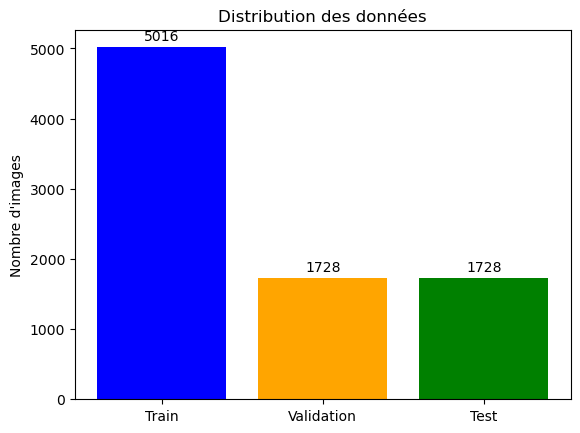

In [6]:
# visualisation des statistiques du dataset

values = [len(train_dataset), len(val_dataset), len(test_dataset)]
labels = ['Train', 'Validation', 'Test']
#plt.bar(labels, values, color=['blue', 'orange', 'green'])
plt.bar_label(plt.bar(labels, values, color=['blue', 'orange', 'green']), padding=3)
plt.title('Distribution des données')
plt.ylabel('Nombre d\'images')
plt.show()


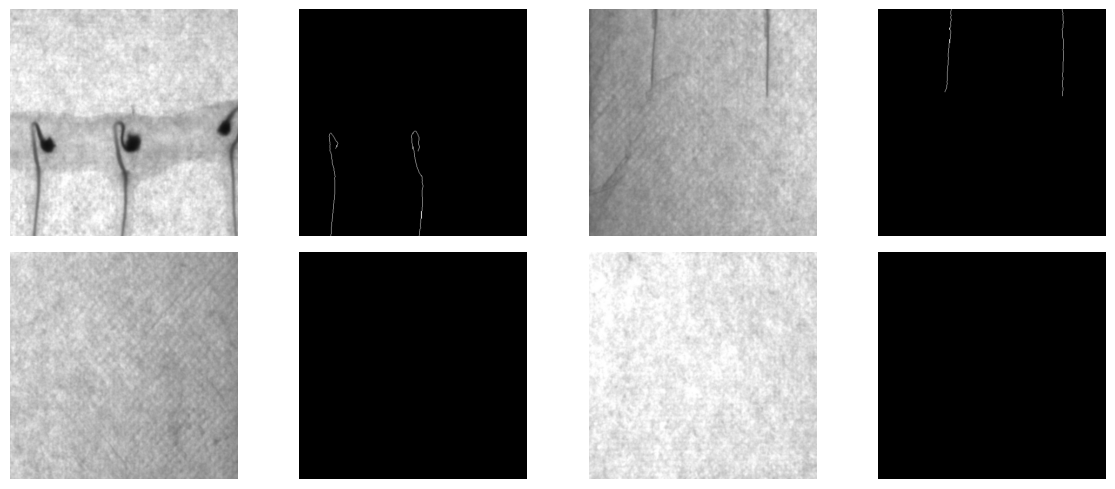

In [8]:
# visualisation des exemples
n = np.random.randint(0, len(train_dataset), size=8)

fig, axes = plt.subplots(2, 4, figsize=(12, 5), facecolor='white')

axes = axes.flatten()
for i in range(0, len(n), 2):
    image, mask = train_dataset[n[i]]
    
    axes[i].axis('off')
    axes[i].imshow(image.permute(1, 2, 0).numpy())
    axes[i+1].imshow(mask.squeeze().numpy(), cmap='gray')
    axes[i+1].axis('off')


plt.tight_layout()
plt.show()

In [9]:

file_path = os.path.join(src,'checkpoints',f'training_history_{model_name}.json')

with open(file_path, 'r') as f:
    history = json.load(f)

In [10]:
epoch = np.arange(1,len(history["train_loss"])+1)

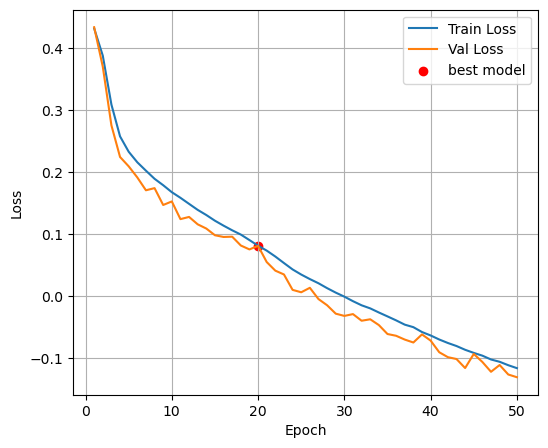

In [11]:
plt.figure(figsize=(6,5))
plt.plot(epoch, history["train_loss"], label="Train Loss")
plt.plot(epoch, history["val_loss"], label="Val Loss")
plt.scatter(history["best_epoch"][-1], history["best_val_loss"][-1], c="red", label = "best model")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()